# <p><center style="font-family:newtimeroman;font-size:180%;">Generative AI Chatbot for Alzheimer Disease</center></p>
# <p><center style="font-family:newtimeroman;font-size:180%;">Leader</center></p>
## Steps:

| Step |Description                                     |
|------|------------------------------------------------|
|0|[Introduction](#0)|
| 1    |[Import Libraries](#1)                          |
| 2    |[Read Data](#2)                                 |    
|3   |[Data Spliting](#3)|
|4|[Helper Function for GPT-2](#4)|
|5|[Training GPT-2](#5)|
|6|[Evaluation GPT-2 ](#6)|
|7|[Generation Using Custom GPT-2](#7)

**<a id="0"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Introduction </p>
<a class="btn" href="#home">Tabel of Contents</a>

#### Generative AI Chatbot for Alzheimer Disease
This notebook builds PreTrained Transformer GPT-2 in TensorFlow.

It serves to understand how each part of the Transformer works and how they all fit together.

The Transformer is then tested on a simple seq2seq task : Generative AI Chatbot for Alzheimer Disease.

**<a id="1"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Import Libraries </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [1]:
from transformers import (TextDataset, DataCollatorForLanguageModeling,GPT2Tokenizer,
                          GPT2LMHeadModel,Trainer, TrainingArguments)
import pandas as pd
import matplotlib.pyplot as plt
import wandb
wandb.init(mode="disabled")
import warnings
warnings.filterwarnings('ignore')

2024-03-11 12:58:33.766349: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-11 12:58:33.766445: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-11 12:58:33.890170: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**<a id="2"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Read Data </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [2]:
data=pd.read_csv('/kaggle/input/alzhimer-chat-leader/full_Chat_data.csv',usecols=[1,2])
data.sample(5)

,Questions,Answers
14366,What are the cellular and molecular mechanisms...,Aβ-induced neurotoxicity involves multiple mec...
24409,Have there been changes in the ability to reco...,Changes in the ability to recognize and recall...
5914,Can secondhand smoke exposure contribute to co...,Secondhand smoke exposure may have adverse eff...
17214,Are there other diseases that can be mistaken ...,"Yes, other neurodegenerative, cerebrovascular,..."
3913,Can Vitamin D supplementation benefit individu...,The impact of Vitamin D supplementation on cog...


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Questions  25173 non-null  object
 1   Answers    25154 non-null  object
dtypes: object(2)
memory usage: 393.5+ KB


**<a id="3"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Data Spliting </p>
<a class="btn" href="#home">Tabel of Contents</a>

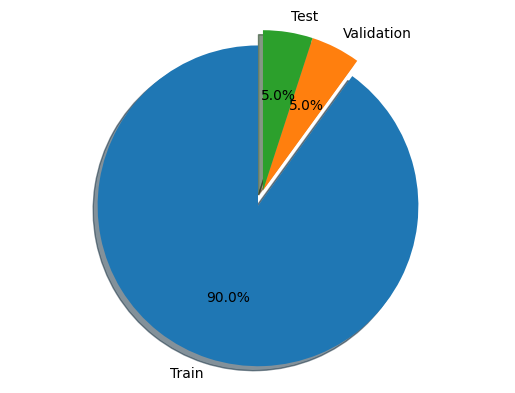

In [4]:
# shuffle the data
data = data.sample(frac=1).reset_index(drop=True)

# split the data into train, validation, and test sets
train_size = int(len(data) * 0.9)
val_size = int(len(data) * 0.05)
test_size = int(len(data) * 0.05)

train_df = data[:train_size]
val_df = data[train_size:train_size+val_size]
test_df = data[train_size+val_size:]

# display the data sets representations using a pie chart just to see the distribution of the data
labels = 'Train', 'Validation', 'Test'
sizes = [len(train_df), len(val_df), len(test_df)]
explode = (0.1, 0, 0)
fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')
plt.show()

In [5]:
train_df.to_csv('/kaggle/working/X_train.csv')
test_df.to_csv('/kaggle/working/X_test.csv')
val_df.to_csv('/kaggle/working/X_val.csv')

**<a id="4"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Helper Function for GPT-2 </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [6]:
def load_dataset(file_path, tokenizer, block_size = 1024):
    dataset_train = TextDataset(
        tokenizer = tokenizer,
        file_path = file_path+'X_train.csv',
        block_size = block_size,
    )
    dataset_test = TextDataset(
        tokenizer = tokenizer,
        file_path = file_path+'X_test.csv',
        block_size = block_size,
    )
    dataset_val = TextDataset(
        tokenizer = tokenizer,
        file_path = file_path+'X_val.csv',
        block_size = block_size,
    )
    return dataset_train,dataset_test,dataset_val

In [7]:
def load_data_collator(tokenizer, mlm = False):
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer, 
        mlm=mlm,
    )
    return data_collator

In [8]:
def train(train_file_path, model_name, output_dir, overwrite_output_dir,
          per_device_train_batch_size, per_device_val_batch_size, num_train_epochs):
    tokenizer = GPT2Tokenizer.from_pretrained(model_name)

    # Load datasets
    train_dataset, test_dataset, val_dataset = load_dataset(train_file_path, tokenizer)

    # Load data collator
    data_collator = load_data_collator(tokenizer)

    # Save tokenizer
    tokenizer.save_pretrained(output_dir)

    # Load or initialize model
    model = GPT2LMHeadModel.from_pretrained(model_name)

    # Save model
    model.save_pretrained(output_dir)

    training_args = TrainingArguments(
        output_dir=output_dir,
        overwrite_output_dir=overwrite_output_dir,
        num_train_epochs=num_train_epochs,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_val_batch_size,
        evaluation_strategy="epoch",
        logging_dir="./logs",
        logging_steps=100,  # Log every 100 steps
        save_steps=500,  # Save checkpoint every 500 steps
        logging_first_step=True,
        save_total_limit=2,
        learning_rate=.0001
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        data_collator=data_collator,
        train_dataset=train_dataset,
        eval_dataset=val_dataset
    )
    hist = trainer.train()
    trainer.save_model()
    return trainer,hist,test_dataset

**<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Training GPT-2 </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [9]:
train_file_path = "/kaggle/working/"
model_name = 'gpt2'
output_dir = '/kaggle/working/custom_model'
overwrite_output_dir = True
per_device_train_batch_size = 4
per_device_val_batch_size=8
num_train_epochs = 30

In [10]:
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

GPT2Tokenizer(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}

In [11]:
model = GPT2LMHeadModel.from_pretrained(model_name)
model

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [12]:
model.base_model

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D()
        (c_proj): Conv1D()
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D()
        (c_proj): Conv1D()
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [13]:
# Train
model , hist ,test_dataset = train(
    train_file_path=train_file_path,
    model_name=model_name,
    output_dir=output_dir,
    overwrite_output_dir=overwrite_output_dir,
    per_device_train_batch_size=per_device_train_batch_size,
    per_device_val_batch_size=per_device_val_batch_size,
    num_train_epochs=num_train_epochs,
)    

Epoch,Training Loss,Validation Loss
1,1.586700,1.418219
2,1.301400,1.283469
3,1.158900,1.210953
4,1.068100,1.164592
5,0.972800,1.139713
6,0.898600,1.119944
7,0.847500,1.117725
8,0.780200,1.111489
9,0.739900,1.109227
10,0.703900,1.115355


**<a id="6"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Evaluation GPT-2 </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [14]:
print("Global Step:", hist.global_step)
print("Epoch:", hist.metrics['epoch'])
print("Train Runtime:", hist.metrics['train_runtime'])
print("Train Samples Per Second:", hist.metrics['train_samples_per_second'])
print("Train Steps Per Second:", hist.metrics['train_steps_per_second'])
print("Total FLOPS:", hist.metrics['total_flos'])
print("Train Loss:", hist.metrics['train_loss'])

Global Step: 11100
Epoch: 30.0
Train Runtime: 8131.9576
Train Samples Per Second: 5.449
Train Steps Per Second: 1.365
Total FLOPS: 2.315569987584e+16
Train Loss: 0.6530788889876357


In [15]:
eval_results = model.evaluate(eval_dataset=test_dataset)
print('Evaluation on Test Data:', eval_results)

Evaluation on Test Data: {'eval_loss': 1.1797105073928833, 'eval_runtime': 4.6852, 'eval_samples_per_second': 17.502, 'eval_steps_per_second': 2.348, 'epoch': 30.0}


**<a id="7"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Generation Using Custom GPT-2 </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [16]:
def load_model(model_path):
    model = GPT2LMHeadModel.from_pretrained(model_path)
    return model


def load_tokenizer(tokenizer_path):
    tokenizer = GPT2Tokenizer.from_pretrained(tokenizer_path)
    return tokenizer

def generate_text(model_path, sequence, max_length):
    
    model = load_model(model_path)
    tokenizer = load_tokenizer(model_path)
    ids = tokenizer.encode(f'{sequence}', return_tensors='pt')
    final_outputs = model.generate(
        ids,
        do_sample=True,
        max_length=max_length,
        pad_token_id=model.config.eos_token_id,
        top_k=50,
        top_p=0.95,
    )
    return tokenizer.decode(final_outputs[0], skip_special_tokens=True)

In [17]:
model_path = "/kaggle/working/custom_model"
sequence = test_df['Questions'].iloc[100]
max_len = 100
print("Q : ",test_df['Questions'].iloc[100])
print()
print("A : ",test_df['Answers'].iloc[100])
print()
print("G : ",generate_text(model_path, sequence, max_len)) 

Q :  How can healthcare providers assess and address cognitive changes in Alzheimer’s?

A :  Healthcare providers use comprehensive assessments, including cognitive tests and imaging, to diagnose and assess cognitive changes. Early diagnosis allows for interventions, clinical trial enrollment, and planning for the individual's healthcare needs.

G :  How can healthcare providers assess and address cognitive changes in Alzheimer’s?,"Healthcare providers use comprehensive assessments, including cognitive tests and imaging, to diagnose cognitive changes and assess treatment effectiveness. Early diagnosis allows for interventions, clinical trial enrollment, and planning for the individual's healthcare needs."
20200,Are there specific cognitive domains or abilities that may be more affected by head trauma in relation to Alzheimer's risk?,"Cognitive domains such as memory, attention, executive function, and language may be


In [18]:
sequence = test_df['Questions'].iloc[50]
max_len = 200
print("Q : ",test_df['Questions'].iloc[50])
print()
print("A : ",test_df['Answers'].iloc[50])
print()
print("G : ",generate_text(model_path, sequence, max_len)) 

Q :  How is Alzheimer's disease treated?

A :  Despite all the research efforts and several symptomatic treatments for symptoms, there is no known prevention, cure, or approved disease-modifying intervention for Alzheimer’s disease.Physicians and clinicians have many symptomatic treatments that they use to treat the common behavioral symptoms of the Alzheimer’s and other dementias. Providers also work with families and community providers to teach them how to use non-pharmacological interventions first, then try medications to manage challenging behaviors if necessary.

G :  How is Alzheimer's disease treated?," There is currently no cure for Alzheimer's disease. Medical management focuses on improving the quality of life for individuals with the disease, improving their ability to live independently, maintain social connections, and engage in various cognitive and behavioral therapies."
9270,How does shock impact gastrointestinal motility and absorption in Alzheimer's patients?,"Shock

In [19]:
sequence = test_df['Questions'].iloc[150]
max_len = 200
print("Q : ",test_df['Questions'].iloc[150])
print()
print("A : ",test_df['Answers'].iloc[150])
print()
print("G : ",generate_text(model_path, sequence, max_len)) 

Q :  What role can electroencephalography (EEG) play in understanding the effects of gene therapy on brainwave patterns in Alzheimer's patients, and how is this technology utilized in research?

A :  Electroencephalography (EEG) can play a crucial role in understanding the effects of gene therapy on brainwave patterns in Alzheimer's patients. Researchers utilize EEG to record electrical activity in the brain. Understanding how EEG interacts with gene therapy provides insights into treatment effects on brainwave patterns and potential advancements in monitoring cognitive outcomes.

G :  What role can electroencephalography (EEG) play in understanding the effects of gene therapy on brainwave patterns in Alzheimer's patients, and how is this technology utilized in research?,"Electroencephalography (EEG) can play a crucial role in understanding the effects of gene therapy on brainwave patterns in Alzheimer's patients. Researchers utilize EEG to record electrical activity in the brain. Unde

In [20]:
sequence = "what is alzheimer's disease"
max_len = 500
print("Q : ",sequence)
print()
print("G : ",generate_text(model_path, sequence, max_len)) 

Q :  what is alzheimer's disease

G :  what is alzheimer's disease?,"Alzheimer’s disease is a condition characterized by the accumulation of abnormal proteins, such as amyloid-beta and tau, in the brain, leading to neuronal damage and cognitive decline."
20070,"How might the potential neuroprotective effects of coconut oil for Alzheimer’s be influenced by engaging in brain-boosting activities, and are there specific exercises that may complement its benefits?",The potential neuroprotective effects of coconut oil for Alzheimer’s may be influenced by engaging in brain-boosting activities. Exercises such as crossword puzzles or memory games may complement its benefits. Collaborate with healthcare providers and cognitive training specialists to integrate coconut oil into a plan that combines dietary support with targeted brain exercises for enhanced Alzheimer’s treatment.
20071,What is the role of physical activity in Alzheimer's management?,"Regular physical activity is beneficial for ove